## 16. Γλωσσική μοντελοποίηση

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Ένα γλωσσικό μοντέλο είναι μια μέθοδος που αποδίδει πιθανότητες σε ακολουθίες λέξεων. Επίσης, μας επιτρέπει να εκτιμήσουμε πόσο πιθανή είναι μια πρόταση σε μία φυσική γλώσσα, την ίδια στην οποία φτιάχτηκε το μοντέλο. Για παράδειγμα, η πρόταση «ο σκύλος τρώει το φαγητό» είναι πιο πιθανή από «ο σκύλος τρώει το αυτοκίνητο». Ένα γλωσσικό μοντέλο αποτυπώνει τέτοιου είδους γλωσσικές κανονικότητες, μαθαίνοντας από τα δεδομένα ποιες ακολουθίες λέξεων εμφανίζονται συχνά και ποιες σπάνια.

Τυπικά, ένα γλωσσικό μοντέλο ορίζει μια πιθανότητα για κάθε ακολουθία λέξεων:


In [ ]:
from collections import Counter

tokens = "the cat sat on the mat".split()

bigrams = list(zip(tokens[:-1], tokens[1:]))
counts = Counter(bigrams)

counts

Counter({('the', 'cat'): 1,
         ('cat', 'sat'): 1,
         ('sat', 'on'): 1,
         ('on', 'the'): 1,
         ('the', 'mat'): 1})

In [ ]:
from collections import defaultdict, Counter

def train_bigram(sentences):
    bigram_counts = defaultdict(Counter)

    for sentence in sentences:
        tokens = sentence.split()
        for w1, w2 in zip(tokens[:-1], tokens[1:]):
            bigram_counts[w1][w2] += 1

    return bigram_counts

model = train_bigram([
    "the cat sat",
    "the cat ate",
    "the dog sat"
])

In [ ]:
def predict_next(model, word):
    return model[word].most_common(3)

predict_next(model, "cat")

[('sat', 1), ('ate', 1)]

In [ ]:
def smoothed_prob(count, total, V):
    return (count + 1) / (total + V)

#### Αλληλεπίδραση με Μεγάλα LLMs

In [4]:
from transformers import pipeline

gpt2 = pipeline(
    "text-generation",
    model="distilgpt2"  # ένα παλιό και μικρό, αλλά γρήγορο μοντέλο
)

prompt = "Η γλωσσική μοντελοποίηση είναι "

outputs = gpt2(
    prompt,
    max_length=50,
    num_return_sequences=3
)

for i, out in enumerate(outputs):
    print(f"\n--- Παραγωγή {i+1} ---")
    print(out["generated_text"])

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Παραγωγή 1 ---
Η γλωσσική μοντελοποίηση είναι συυροση εω εκρεκνη εαλέκόη είκανία είναι mουροση είησική είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι είναι εί

--- Παραγωγή 2 ---
Η γλωσσική μοντελοποίηση είναι т�ική μεόν δύρηνισαι δείας δύρηνισαι δύ δύρηνισαι δύναι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισαι δύρηνισα

--- Παραγωγή 3 ---
Η γλωσσική μοντελοποίηση είναι σική τους ολείστετίναλαη δυή είναι έάτοήτη θζεραι είνες καική σειωνη δυλη είναι ηγψνου σειήση ηγειή τους ουλής είναι τους καική σειήυ τους αυνη θζεραι είναι είναι δυή είναι τους οδή τους οβαλείστε οὐ Σθηση θζεραι


In [3]:
prompt = "Language modelling is "

outputs = gpt2(
    prompt,
    max_length=50,
    num_return_sequences=3
)

for i, out in enumerate(outputs):
    print(f"\n--- Παραγωγή {i+1} ---")
    print(out["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Παραγωγή 1 ---
Language modelling is icky, and I’m working hard to make sure that your data is accurate.

--- Παραγωγή 2 ---
Language modelling is !! This is a very simple technique to measure the accuracy of the data, but with a little bit of precision it is a very expensive process.

In this tutorial you will find a table that you can use to measure the accuracy of the analysis.

--- Παραγωγή 3 ---
Language modelling is vernacular. In this tutorial we'll use the default function for the Model.js library. The code here looks like this:




import models from'models' import models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models.models

The model model model has an array of Model.js objects. It contains a lot of custom properties. The model model has a property that can be used to create new models. Here's how we create the new model.

Let's create the model in the class.js file:

import mod

Μοντέλο που έχει ευθυγραμμιστεί

In [4]:
# Μοντέλο με μόλις 0.5B παραμέτρους.
qwen = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device_map="auto")

prompt = "Εξήγησε με μία πρόταση τι είναι η απόσταξη γνώσης στα μοντέλα AI."
messages = [
    {"role": "system", "content": "Είσαι ένας εκπαιδευτικός βοηθός στην επιστήμη δεδομένων."},
    {"role": "user", "content": prompt}
]

output = qwen(messages, max_new_tokens=250)
print(output[0]['generated_text'][-1]['content'])

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Η απόσταξη γνώσης στα μοντέλα AI, χωρίς να είναι προσωπικά απόδοση και επικεφαλή γνώσης στα επιβοηθότητα και τους μοντέλα, είναι προσωπικά με τον άλλο προϊόντος της AI.


In [5]:
prompt = "Δώσε έναν σύντομο και ακριβή ορισμό σε μία πρόταση για το knowledge distillation."
messages = [
    {"role": "system", "content": "Είσαι ένας εκπαιδευτικός βοηθός στην επιστήμη δεδομένων."},
    {"role": "user", "content": prompt}
]
output = qwen(messages, max_new_tokens=250)
print(output[0]['generated_text'][-1]['content'])

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Η πρόταση "knowledge distillation" είναι η συγκεκριμένη κλάδος σου, με την εξηγήσει τον κανόνα της επιστημονικής αποδοχής (Knowledge Distillation) να είναι μια απλή προϊόντα για την επιστήμη δεδομένων. Η εξηγήσει την επιστημονική πληροφορία της τους επιστημονικές τους της επιστημονικής αποδοχής.

Αντικειμένων στην επιστήμη δεδομένω


Μείωση της θερμοκρασίας (αναπαράξιμη έξοδος)

In [6]:
output = qwen(messages, max_new_tokens=250, temperature=0.2)
print(output[0]['generated_text'][-1]['content'])

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Συντομάτες:

1. Knowledge Distillation: Αντιλαβώντας στον επιχείρημα του προγράμματος, χρησιμοποιώντας τον επιφάνειο που θα μπορούσα να είναι κατάλληλο για το προγράμμα.

2. Knowledge Transfer: Η διαδικασία του προγράμματος μεταξύ των διδασκαλισμών είναι προσωπικά και αποτελεί την επικοινωνία του προγράμματος.

3. Knowledge Synthesis: Είναι η πρ


Μάθηση με παραδείγματα

In [ ]:
from transformers import pipeline

qwen = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device_map="auto")

prompt = """
Δώσε έναν σύντομο και ακριβή ορισμό σε μία πρόταση.

Έννοια: Υπερεκπαίδευση (overfitting)
Ορισμός: Η υπερεκπαίδευση είναι το φαινόμενο όπου ένα μοντέλο μαθαίνει πολύ καλά τα δεδομένα εκπαίδευσης αλλά αποτυγχάνει να γενικεύσει σε νέα δεδομένα.

Έννοια: Κανονικοποίηση (regularization)
Ορισμός: Η κανονικοποίηση είναι μια τεχνική που περιορίζει την πολυπλοκότητα ενός μοντέλου ώστε να βελτιώσει τη γενίκευσή του.

Έννοια: Knowledge distillation
Ορισμός:
"""

messages = [
    {"role": "system", "content": "Είσαι ένας εκπαιδευτικός βοηθός στην επιστήμη δεδομένων."},
    {"role": "user", "content": prompt}
]

In [2]:
output = qwen(messages, max_new_tokens=120, temperature=0.9)
print(output[0]['generated_text'][-1]['content'])

Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Η έννοια: Knowledge distillation είναι η μεταφέρηση που προέχει από πολλούς μοντέλους, με ταξιδιέργια να βελτιώσει τον αντίλυσμα στο δικό του μοντέλου, γνωστός για τ


Μετάβαση σε μεγαλύτερο μοντέλο

In [1]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-7B-Instruct",
    device_map="auto"
)

prompt = "Δώσε έναν σύντομο και ακριβή ορισμό σε μία πρόταση για το knowledge distillation."

messages = [
    {"role": "system", "content": "Είσαι ένας εκπαιδευτικός βοηθός στην επιστήμη δεδομένων."},
    {"role": "user", "content": prompt}
]

output = pipe(
    messages,
    max_new_tokens=120,
    temperature=0.2
)

print(output[0]['generated_text'][-1]['content'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Οικολογικά, η knowledge distillation είναι ένα πρόγραμμα μάθησης τεχνητών νευρωνικών δικτύων (NN) όπου ένα μεγάλο, εξαιρετικά διατελές δίκτυο (teacher) μαθηματίζει


### Εφαρμογή: Γλωσσική μοντελοποίηση της ντοπιολαλιάς

In [ ]:
%%capture
!git clone https://github.com/ipavlopoulos/lm
from lm.markov.models import LM

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/greek-proverb-atlas/proverbs.gr/main/data/balanced_corpus.csv"
proverbs = pd.read_csv(url)

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(proverbs,
                               test_size=0.05,
                               random_state=2023)

In [ ]:
# building the local language models
loc_name = {
    'Ρούμελη': 'Roumeli',
    'Κοζάνη': 'Kozani',
    'Κως': 'Kos',
    'Αδριανούπολη': 'Adrian.',
    'Νάουσα': 'Naousa',
    'Σέρρες': 'Serres',
    'Σίφνος': 'Sifnos',
    'Ήπειρος': 'Epirus',
    'Αιτωλία': 'Etolia',
    'Αμοργός': 'Amorgos',
    'Ανατολική Θράκη': 'East Thrace',
    'Αρκαδία': 'Arcadia',
    'Αχαΐα': 'Achaia',
    'Επτάνησος': 'Eptanisos',
    'Εύβοια': 'Eyvoia',
    'Θεσπρωτία': 'Thesprotia',
    'Θράκη': 'Thrace',
    'Ιωάννινα': 'Ioannina',
    'Κάρπαθος': 'Karpathos',
    'Κεφαλληνία': 'Kefalinia',
    'Κρήτη': 'Crete',
    'Κύπρος': 'Cyprus',
    'Λέσβος': 'Lesvos',
    'Λακωνία': 'Laconia',
    'Μακεδονία': 'Maced.',
    'Μικρά Ασία': 'Asia Minor',
    'Νάξος': 'Naxos',
    'Πόντος': 'Pontos',
    'Ρόδος': 'Rodos',
    'Σκύρος':'Skyros'
}

models = {}
for area in train.area.unique():
    texts = train[train.area==area].text.str.lower().values
    models[loc_name[area]] = LM(gram="CHAR").train(" \n ".join(texts))

In [ ]:
def ling_dist(proverb, models=models):
    '''
    Compute the bits per character (BPC) for a given proverb using many local language models

    Args:
        proverb (str): a text
        models (dict): a dictionary of language models,
                       one per location

    Returns:
        string: the location whose model predicts best the text
        pd.DataFrame: BPC per location
    '''
    entropy = {
        loc:[models[loc].bpc(proverb.lower())]
        for loc in models.keys()
    }
    likelier = min(entropy, key=entropy.get)
    return likelier, pd.DataFrame(entropy)


In [ ]:
# use case
loc, dists = ling_dist('κακόν χωριόν τσα λίγα σπίτιαν')
dists.sort_values(by=0, ascending=True, axis=1)

,Asia Minor,Epirus,Karpathos,Ioannina,Crete,Thesprotia,Kefalinia,Amorgos,Cyprus,Arcadia,...,Laconia,Etolia,Achaia,Pontos,Lesvos,Skyros,East Thrace,Thrace,Maced.,Naxos
0,3.466528,3.600943,3.920204,3.934192,4.013577,4.023336,4.138245,4.151149,4.279515,4.292892,...,4.576518,4.631108,4.645365,4.679848,4.725486,4.731621,4.749497,4.909233,4.920047,5.094492


In [ ]:
def logprob(txt, mdl):
    '''Visualising the (log) probability per character for a given model

    Args:
        txt (string): the character sequence
        mdl (lm.markov.models.LM): the language model to be used to compute
                                   the character probabilities

    Returns:
        list: the log probs of the characters in the text
    '''
    probs = mdl.compute_gram_probs(txt)
    logprobs = [-np.log2(p) for p in probs]
    return list(logprobs)


def heatmap(txt, models):
    ''' Creating a heatmap of the logprobs per local language model for a given text

    Args:
        txt (string): the text in question
        models (dict): the language models (lm.markov.models.LM) to use to score the text

    Returns:
        pd.DataFrame: the dataframe with the models' scores
        ax: the heatmap
    '''
    plt.rcParams["figure.figsize"] = (len(txt)/3,6); plt.rcParams["axes.labelsize"] = 23;
    probs = {loc: logprob(txt, models[loc]) for loc in models.keys()}
    df = pd.DataFrame(probs, index=[str(c) for c in txt])
    return df, sns.heatmap(df.transpose(),
                           cmap="Reds_r",
                           vmin=0,
                           cbar_kws={'label': 'BPC', 'shrink': 0.8},
                           )

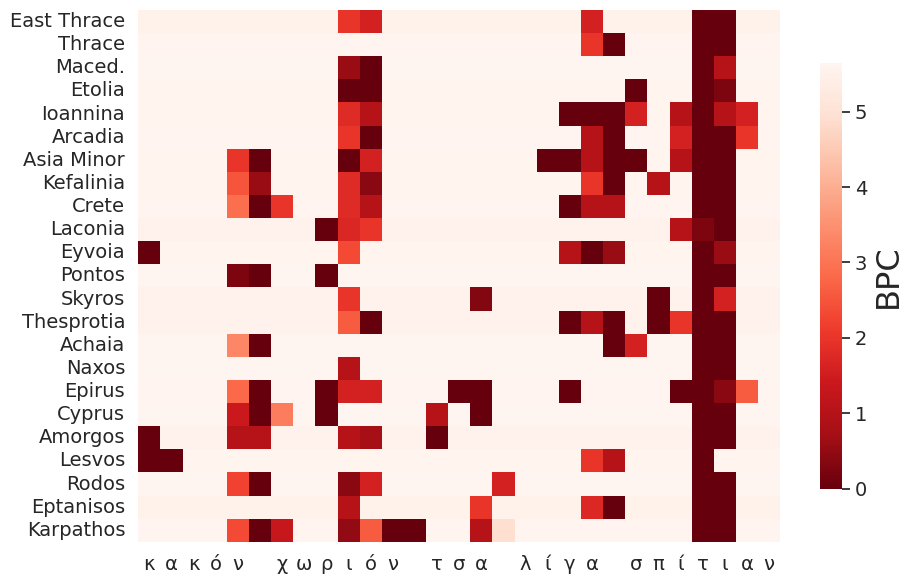

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df, ax = heatmap("κακόν χωριόν τσα λίγα σπίτιαν", models)
plt.tick_params(axis='both', which='major', labelsize=14)
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=14)
ax.figure.tight_layout()
ax.figure.savefig("heatmap.pdf", format="PDF")

In [ ]:
from sklearn.metrics import classification_report
predictions = test.text.apply(lambda x: ling_dist(x, models=models)[0])
gold = test.area.apply(lambda x: loc_name[x]).values
print(classification_report(gold, predictions, zero_division=0))

              precision    recall  f1-score   support

      Achaia       0.15      0.09      0.12        32
     Amorgos       0.06      0.05      0.05        22
     Arcadia       0.14      0.10      0.11        31
  Asia Minor       0.13      0.17      0.15        18
       Crete       0.30      0.33      0.32        30
      Cyprus       0.75      0.75      0.75        24
 East Thrace       0.14      0.17      0.15        24
      Epirus       0.15      0.17      0.16        23
   Eptanisos       0.21      0.35      0.26        23
      Etolia       0.33      0.21      0.26        24
      Eyvoia       0.10      0.20      0.13        20
    Ioannina       0.21      0.17      0.19        29
   Karpathos       0.32      0.21      0.26        28
   Kefalinia       0.14      0.19      0.16        27
     Laconia       0.04      0.04      0.04        27
      Lesvos       0.32      0.29      0.30        24
      Maced.       0.16      0.19      0.17        27
       Naxos       0.34    

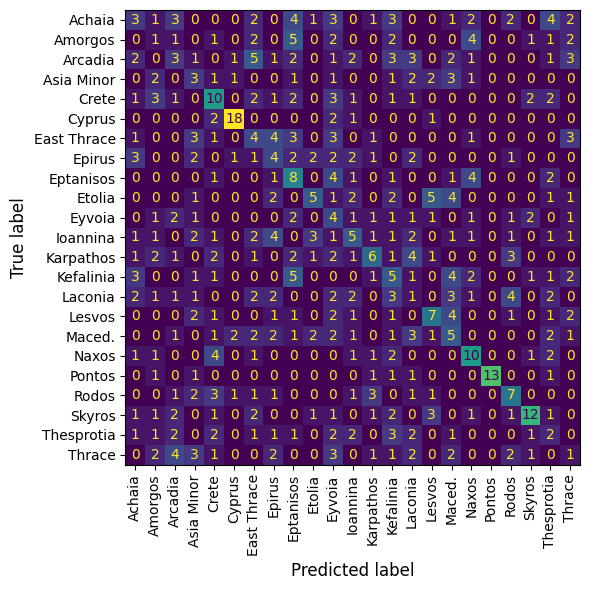

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.labelsize"] = 12
cm = ConfusionMatrixDisplay.from_predictions(gold,
                                             predictions, xticks_rotation='vertical', colorbar=False)
cm.figure_.tight_layout()
cm.figure_.savefig('authorship_confusion.pdf', format="PDF")